In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import pickle as pkl
import networkx as nx
import matplotlib.pyplot as plt

import good
from good.reload import deep_reload

This nodebook shows an example of how to run GOOD for a pre-build graph. In this case the WECC example graph is loaded and run for 7 days with results plotted. The same is done with flexible base loads in the second example.

The first step is to load the graph. Let's use the WECC example.

In [2]:
graph = good.graph.graph_from_json('Examples/WEC.json')

graph.nodes

NodeView(('WECC_AZ', 'WECC_CO', 'WECC_ID', 'WECC_IID', 'WECC_MT', 'WECC_NM', 'WECC_NNV', 'WECC_PNW', 'WECC_SCE', 'WECC_SNV', 'WECC_UT', 'WECC_WY', 'WEC_BANC', 'WEC_CALN', 'WEC_LADW', 'WEC_SDGE'))

Let's make this sepcific to California by making a subgraph

In [3]:
graph = good.graph.subgraph(graph, [n for n in graph.nodes if 'WEC_' in n])

First we will consider the current grid with no capacity expanison and no load shifting.

In [4]:
'''
Loading graph and policies - with no capex
'''
deep_reload(good)

graph = good.graph.graph_from_json('Examples/WEC.json')

graph = good.graph.subgraph(graph, [n for n in graph.nodes if 'WEC_' in n])

policies = good.utilities.read_json('Examples/RPS.json')

for source, node in graph._node.items():
    for asset in node.get('assets', []):

        asset['capex_capacity'] = 0

In [5]:
graph.nodes
graph._node['WEC_CALN']['assets'][0]['operating_cost'] *=3

In [6]:
'''
Building from graph
'''
deep_reload(good)

kw = {
    'verbose': True,
    'steps': (6 * 32 * 24, 6 * 32 * 24 + 24 * 7),
    'shortfall_capacity': np.inf,
    'shortfall_cost': 1e3,
    'wastage_capacity': np.inf,
    'wastage_cost': 1e3,
}

network = good.optimization.network.Network(**kw).from_graph(graph, policies = policies)

'''
Building the model
'''

network.build()

network.size()

Parameters Built: 0.13684892654418945
Variables Built: 0.10633349418640137
Constraints Built: 0.8465285301208496
Objective Built: 0.07246065139770508


ModelSizeReport(activated = Bunch(binary_variables = 0, constraints = 59976, continuous_variables = 32760, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 32760), overall = Bunch(binary_variables = 0, constraints = 59976, continuous_variables = 32760, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 32760), warning = Bunch(unassociated_disjuncts = 0))

In [7]:
'''
Solving the model
'''
deep_reload(good)

kw = {
    'solver': {
        '_name': 'cbc',
    },
}

network.solve(**kw)
results = network.results

Problem Solved: 5.004836559295654
Results Collected: 0.5790421962738037


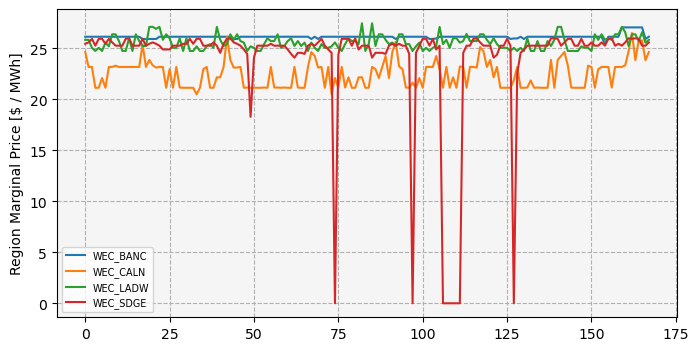

In [8]:
fig, ax = plt.subplots(1, 1, figsize = (8, 4))

for source, node in graph._node.items():

    ax.plot(
        np.array(results[source]['clearing_price']) * 3.6e9,
        label = source,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Region Marginal Price [$ / MWh]',
}

ax.set(**kw)

kw = {
    'ls': '--',
}

ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

ax.legend(**kw)

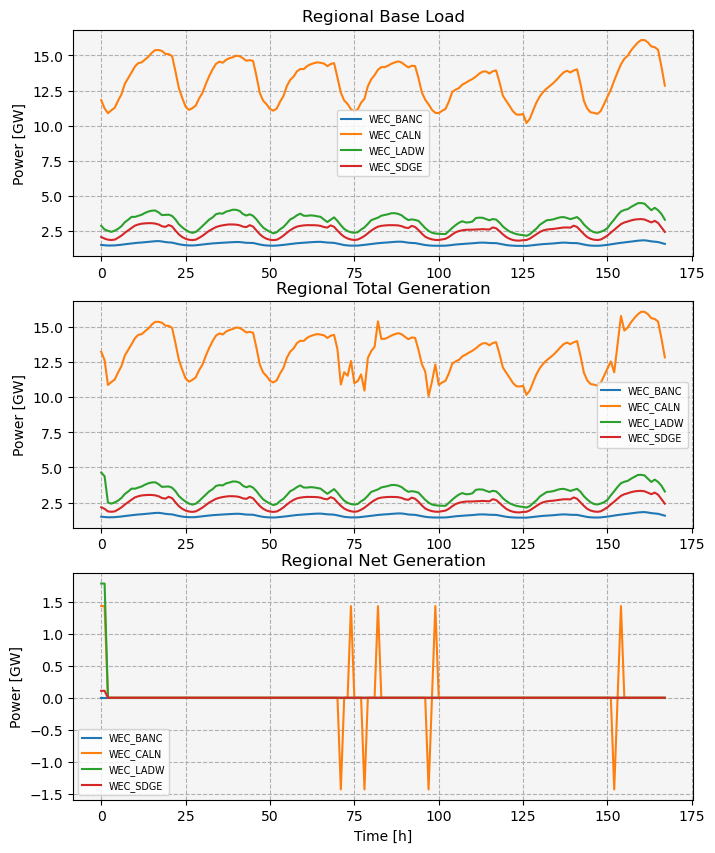

In [9]:
fig, ax = plt.subplots(3, 1, figsize = (8, 10))

for source, node in graph._node.items():

    ax[0].plot(
        -np.array(results[source]['assets'][f"base_load_{source}"]['net']) / 1e9,
        label = source,
    )
    
    ax[0].set_title('Regional Base Load')

for source, node in graph._node.items():

    values = np.vstack(
        [v["net"] for k, v in results[source]['assets'].items() if "base" not in k]
    )

    ax[1].plot(
        values.sum(axis = 0) / 1e9,
        label = source,
    )

    ax[1].set_title('Regional Total Generation')

for source, node in graph._node.items():

    values = np.vstack(
        [v["net"] for k, v in results[source]['assets'].items()]
    )

    ax[2].plot(
        values.sum(axis = 0) / 1e9,
        label = source,
    )

    ax[2].set_title('Regional Net Generation')
    ax[2].set_xlabel('Time [h]')

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = [ax.set(**kw) for ax in ax]

kw = {
    'ls': '--',
}

_ = [ax.grid(**kw) for ax in ax]

kw = {
    'fontsize': 'x-small',
}

_ = [ax.legend(**kw) for ax in ax]

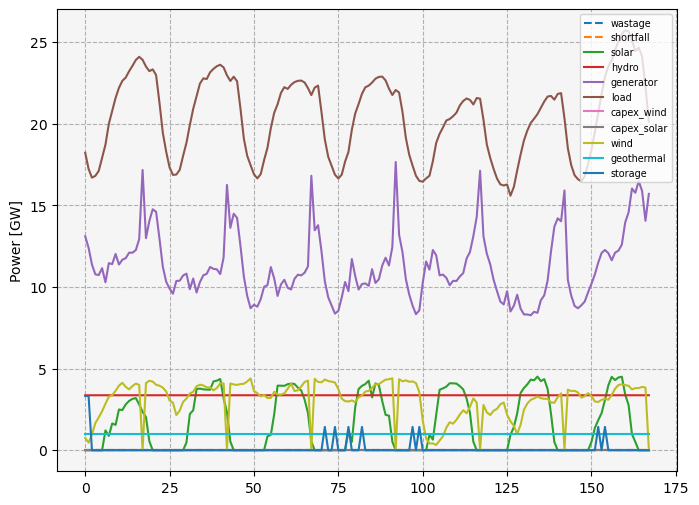

In [10]:
gen_amounts = {'wastage': [], 'shortfall': []}

for source, node in graph._node.items():

    gen_amounts['wastage'].append(network.results[source]['wastage'])
    gen_amounts['shortfall'].append(network.results[source]['shortfall'])

for source, node in graph._node.items():

    for asset in node['assets']:

        if asset['type'] not in gen_amounts:

            gen_amounts[asset['type']] = (
                [network.results[source]['assets'][asset['id']]['net']]
            )

        else:

            gen_amounts[asset['type']].append(
                [network.results[source]['assets'][asset['id']]['net']]
            )
            

for key, val in gen_amounts.items():

    gen_amounts[key] = np.vstack(val).sum(axis = 0) / 1e9

fig, ax = plt.subplots(figsize = (8, 6))

for key, val in gen_amounts.items():

    ax.plot(
        np.abs(val),
        label = key,
        ls = '--' if key in ['wastage', 'shortfall'] else None,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

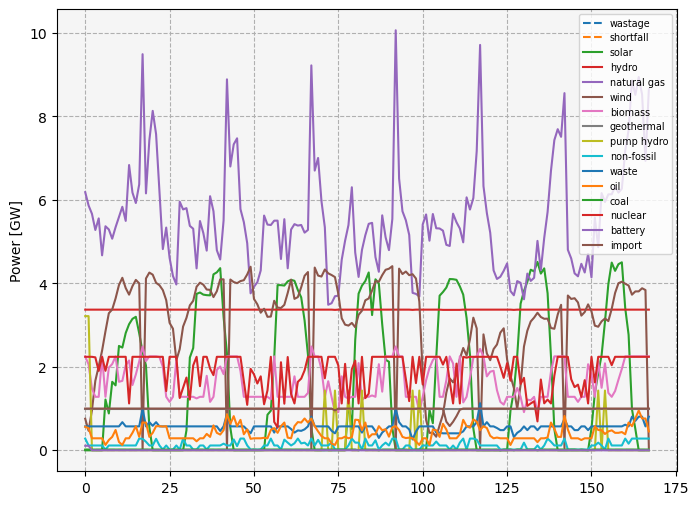

In [11]:
gen_amounts = {'wastage': [], 'shortfall': []}

for source, node in graph._node.items():

    gen_amounts['wastage'].append(network.results[source]['wastage'])
    gen_amounts['shortfall'].append(network.results[source]['shortfall'])

for source, node in graph._node.items():

    for asset in node['assets']:

        if 'fuel' not in asset:

            continue

        if asset['fuel'] not in gen_amounts:

            gen_amounts[asset['fuel']] = (
                [network.results[source]['assets'][asset['id']]['net']]
            )

        else:

            gen_amounts[asset['fuel']].append(
                [network.results[source]['assets'][asset['id']]['net']]
            )

for key, val in gen_amounts.items():

    gen_amounts[key] = np.vstack(val).sum(axis = 0) / 1e9

fig, ax = plt.subplots(figsize = (8, 6))

for key, val in gen_amounts.items():

    ax.plot(
        np.abs(val),
        label = key,
        ls = '--' if key in ['wastage', 'shortfall'] else None,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

Next we will consider the current grid with allowed capacity expanison and no load shifting.

In [12]:
'''
Loading graph and policies
'''
deep_reload(good)

graph = good.graph.graph_from_json('Examples/WEC.json')

graph = good.graph.subgraph(graph, [n for n in graph.nodes if 'WEC_' in n])

policies = good.utilities.read_json('Examples/RPS.json')

In [13]:
'''
Building from graph
'''
deep_reload(good)

kw = {
    'verbose': True,
    'steps': (6 * 32 * 24, 6 * 32 * 24 + 24 * 7),
    'shortfall_capacity': np.inf,
    'shortfall_cost': 1e3,
    'wastage_capacity': np.inf,
    'wastage_cost': 1e3,
}

network = good.optimization.network.Network(**kw).from_graph(graph, policies = policies)

'''
Building the model
'''

network.build()

network.size()

Parameters Built: 0.13533639907836914
Variables Built: 0.308851957321167
Constraints Built: 0.8325107097625732
Objective Built: 0.20796704292297363


ModelSizeReport(activated = Bunch(binary_variables = 0, constraints = 59976, continuous_variables = 32865, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 32865), overall = Bunch(binary_variables = 0, constraints = 59976, continuous_variables = 32865, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 32865), warning = Bunch(unassociated_disjuncts = 0))

In [14]:
'''
Solving the model
'''
deep_reload(good)

kw = {
    'solver': {
        '_name': 'cbc',
    },
}

network.solve(**kw)
results = network.results

Problem Solved: 1.9504168033599854
Results Collected: 0.5817534923553467


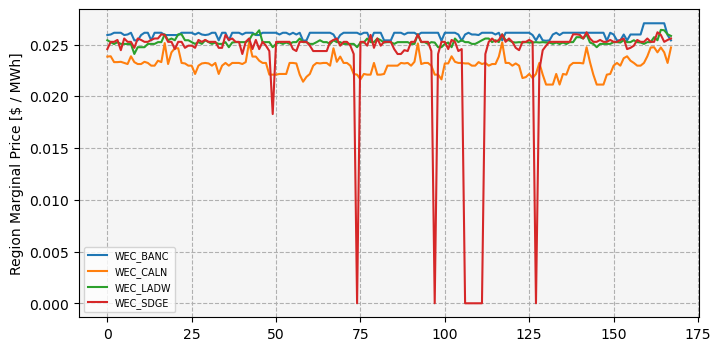

In [15]:
fig, ax = plt.subplots(1, 1, figsize = (8, 4))

for source, node in graph._node.items():

    ax.plot(
        np.array(results[source]['clearing_price']) * 3.6e9,
        label = source,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Region Marginal Price [$ / MWh]',
}

ax.set(**kw)

kw = {
    'ls': '--',
}

ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

ax.legend(**kw)

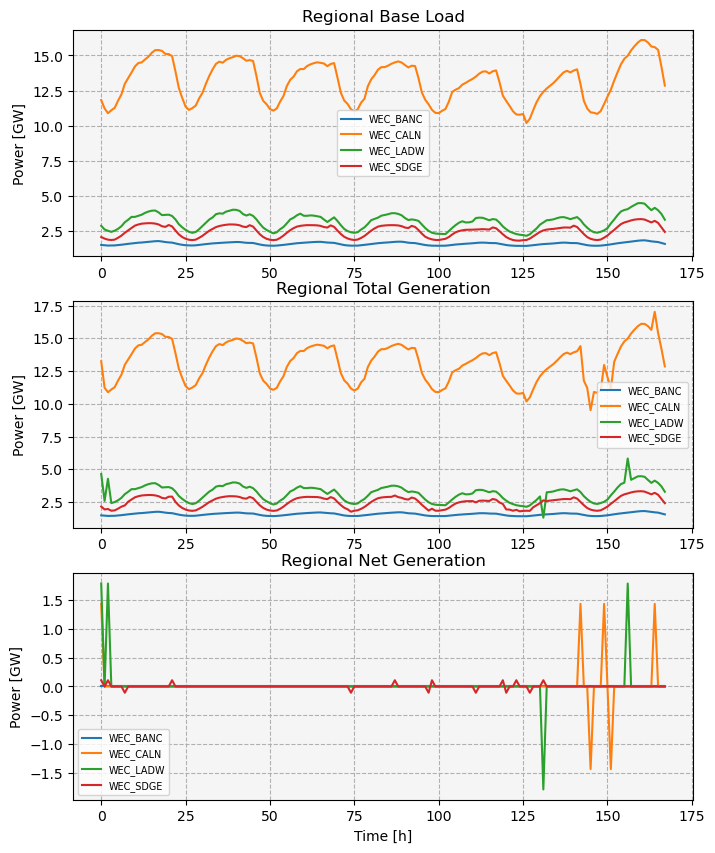

In [16]:
fig, ax = plt.subplots(3, 1, figsize = (8, 10))

for source, node in graph._node.items():

    ax[0].plot(
        -np.array(results[source]['assets'][f"base_load_{source}"]['net']) / 1e9,
        label = source,
    )
    
    ax[0].set_title('Regional Base Load')

for source, node in graph._node.items():

    values = np.vstack(
        [v["net"] for k, v in results[source]['assets'].items() if "base" not in k]
    )

    ax[1].plot(
        values.sum(axis = 0) / 1e9,
        label = source,
    )

    ax[1].set_title('Regional Total Generation')

for source, node in graph._node.items():

    values = np.vstack(
        [v["net"] for k, v in results[source]['assets'].items()]
    )

    ax[2].plot(
        values.sum(axis = 0) / 1e9,
        label = source,
    )

    ax[2].set_title('Regional Net Generation')
    ax[2].set_xlabel('Time [h]')

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = [ax.set(**kw) for ax in ax]

kw = {
    'ls': '--',
}

_ = [ax.grid(**kw) for ax in ax]

kw = {
    'fontsize': 'x-small',
}

_ = [ax.legend(**kw) for ax in ax]

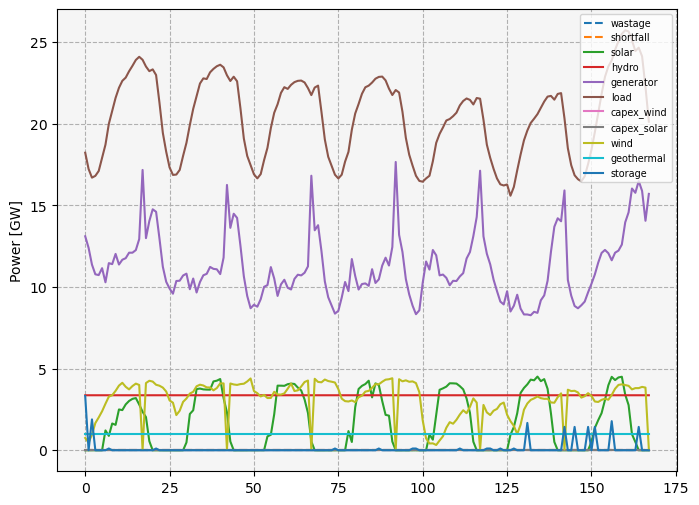

In [17]:
gen_amounts = {'wastage': [], 'shortfall': []}

for source, node in graph._node.items():

    gen_amounts['wastage'].append(network.results[source]['wastage'])
    gen_amounts['shortfall'].append(network.results[source]['shortfall'])

for source, node in graph._node.items():

    for asset in node['assets']:

        if asset['type'] not in gen_amounts:

            gen_amounts[asset['type']] = (
                [network.results[source]['assets'][asset['id']]['net']]
            )

        else:

            gen_amounts[asset['type']].append(
                [network.results[source]['assets'][asset['id']]['net']]
            )
            

for key, val in gen_amounts.items():

    gen_amounts[key] = np.vstack(val).sum(axis = 0) / 1e9

fig, ax = plt.subplots(figsize = (8, 6))

for key, val in gen_amounts.items():

    ax.plot(
        np.abs(val),
        label = key,
        ls = '--' if key in ['wastage', 'shortfall'] else None,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

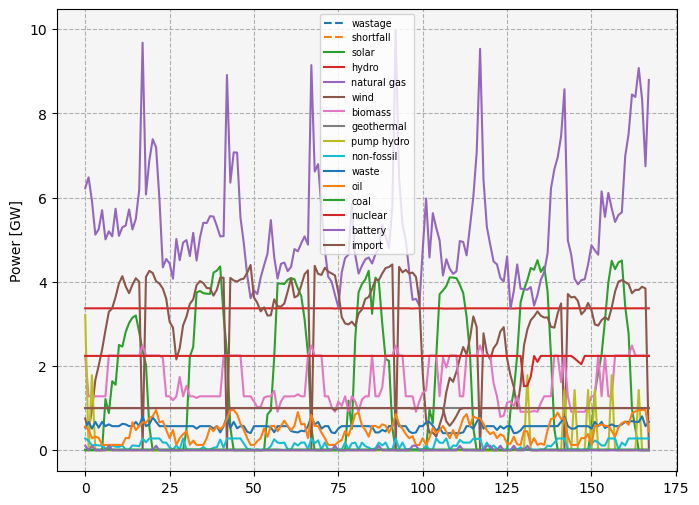

In [18]:
gen_amounts = {'wastage': [], 'shortfall': []}

for source, node in graph._node.items():

    gen_amounts['wastage'].append(network.results[source]['wastage'])
    gen_amounts['shortfall'].append(network.results[source]['shortfall'])

for source, node in graph._node.items():

    for asset in node['assets']:

        if 'fuel' not in asset:

            continue

        if asset['fuel'] not in gen_amounts:

            gen_amounts[asset['fuel']] = (
                [network.results[source]['assets'][asset['id']]['net']]
            )

        else:

            gen_amounts[asset['fuel']].append(
                [network.results[source]['assets'][asset['id']]['net']]
            )

for key, val in gen_amounts.items():

    gen_amounts[key] = np.vstack(val).sum(axis = 0) / 1e9

fig, ax = plt.subplots(figsize = (8, 6))

for key, val in gen_amounts.items():

    ax.plot(
        np.abs(val),
        label = key,
        ls = '--' if key in ['wastage', 'shortfall'] else None,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

Finally we will consider the current grid with allowed capacity expanison and allowed load shifting.

In [19]:
'''
Loading graph and policies - with shifable base load
'''
deep_reload(good)

graph = good.graph.graph_from_json('Examples/WEC.json')

graph = good.graph.subgraph(graph, [n for n in graph.nodes if 'WEC_' in n])

policies = good.utilities.read_json('Examples/RPS.json')

for source, node in graph._node.items():
    for asset in node.get('assets', []):
        
        if asset['type'] == 'load':

            asset['shift_portion'] = .1

In [20]:
'''
Building from graph
'''
deep_reload(good)

kw = {
    'verbose': True,
    'steps': (6 * 32 * 24, 6 * 32 * 24 + 24 * 7),
    'shortfall_capacity': np.inf,
    'shortfall_cost': 1e3,
    'wastage_capacity': np.inf,
    'wastage_cost': 1e3,
}

network = good.optimization.network.Network(**kw).from_graph(graph, policies = policies)

'''
Building the model
'''

network.build()

network.size()

Parameters Built: 0.13242769241333008
Variables Built: 0.11301374435424805
Constraints Built: 0.9117491245269775
Objective Built: 0.21039032936096191


ModelSizeReport(activated = Bunch(binary_variables = 0, constraints = 60652, continuous_variables = 33537, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 33537), overall = Bunch(binary_variables = 0, constraints = 60652, continuous_variables = 33537, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 33537), warning = Bunch(unassociated_disjuncts = 0))

In [21]:
'''
Solving the model
'''
deep_reload(good)

kw = {
    'solver': {
        '_name': 'cbc',
    },
}

network.solve(**kw)
results = network.results

Problem Solved: 1.8014283180236816
Results Collected: 0.6758277416229248


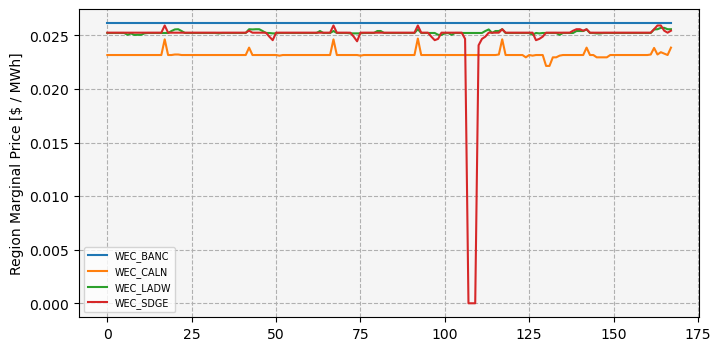

In [22]:
fig, ax = plt.subplots(1, 1, figsize = (8, 4))

for source, node in graph._node.items():

    ax.plot(
        np.array(results[source]['clearing_price']) * 3.6e9,
        label = source,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Region Marginal Price [$ / MWh]',
}

ax.set(**kw)

kw = {
    'ls': '--',
}

ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

ax.legend(**kw)

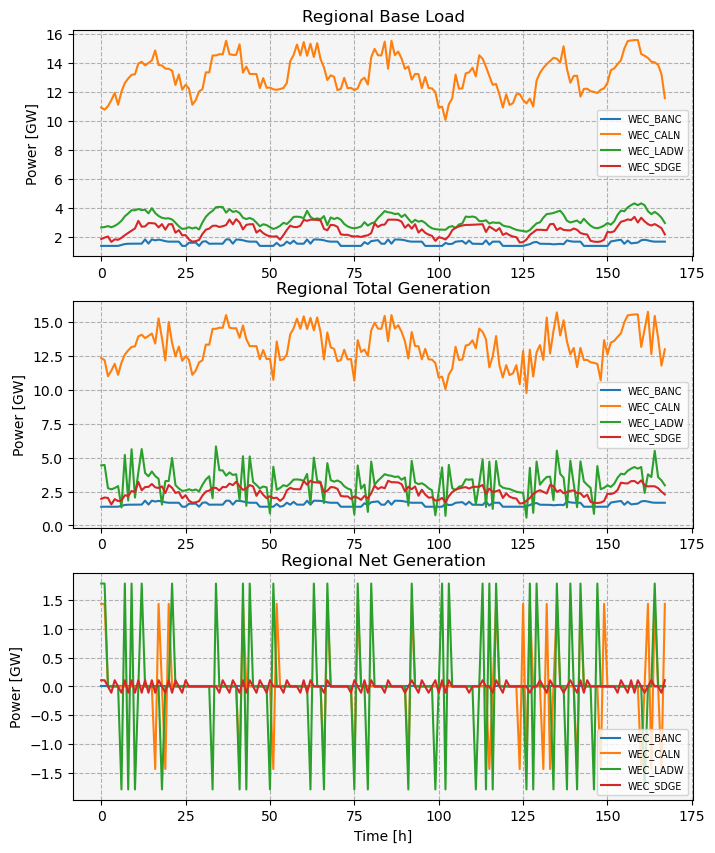

In [23]:
fig, ax = plt.subplots(3, 1, figsize = (8, 10))

for source, node in graph._node.items():

    ax[0].plot(
        -np.array(results[source]['assets'][f"base_load_{source}"]['net']) / 1e9,
        label = source,
    )
    
    ax[0].set_title('Regional Base Load')

for source, node in graph._node.items():

    values = np.vstack(
        [v["net"] for k, v in results[source]['assets'].items() if "base" not in k]
    )

    ax[1].plot(
        values.sum(axis = 0) / 1e9,
        label = source,
    )

    ax[1].set_title('Regional Total Generation')

for source, node in graph._node.items():

    values = np.vstack(
        [v["net"] for k, v in results[source]['assets'].items()]
    )

    ax[2].plot(
        values.sum(axis = 0) / 1e9,
        label = source,
    )

    ax[2].set_title('Regional Net Generation')
    ax[2].set_xlabel('Time [h]')

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = [ax.set(**kw) for ax in ax]

kw = {
    'ls': '--',
}

_ = [ax.grid(**kw) for ax in ax]

kw = {
    'fontsize': 'x-small',
}

_ = [ax.legend(**kw) for ax in ax]

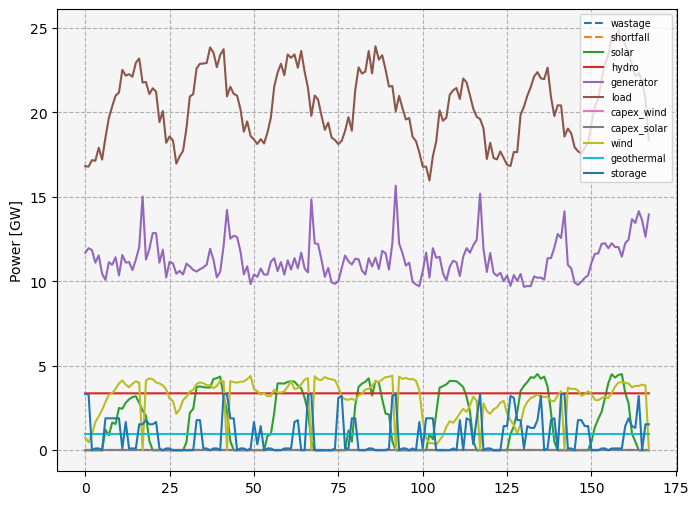

In [24]:
gen_amounts = {'wastage': [], 'shortfall': []}

for source, node in graph._node.items():

    gen_amounts['wastage'].append(network.results[source]['wastage'])
    gen_amounts['shortfall'].append(network.results[source]['shortfall'])

for source, node in graph._node.items():

    for asset in node['assets']:

        if asset['type'] not in gen_amounts:

            gen_amounts[asset['type']] = (
                [network.results[source]['assets'][asset['id']]['net']]
            )

        else:

            gen_amounts[asset['type']].append(
                [network.results[source]['assets'][asset['id']]['net']]
            )
            

for key, val in gen_amounts.items():

    gen_amounts[key] = np.vstack(val).sum(axis = 0) / 1e9

fig, ax = plt.subplots(figsize = (8, 6))

for key, val in gen_amounts.items():

    ax.plot(
        np.abs(val),
        label = key,
        ls = '--' if key in ['wastage', 'shortfall'] else None,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

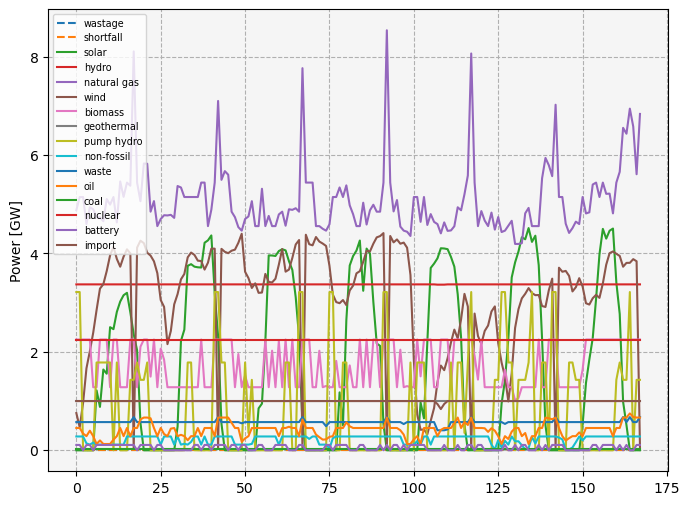

In [25]:
gen_amounts = {'wastage': [], 'shortfall': []}

for source, node in graph._node.items():

    gen_amounts['wastage'].append(network.results[source]['wastage'])
    gen_amounts['shortfall'].append(network.results[source]['shortfall'])

for source, node in graph._node.items():

    for asset in node['assets']:

        if 'fuel' not in asset:

            continue

        if asset['fuel'] not in gen_amounts:

            gen_amounts[asset['fuel']] = (
                [network.results[source]['assets'][asset['id']]['net']]
            )

        else:

            gen_amounts[asset['fuel']].append(
                [network.results[source]['assets'][asset['id']]['net']]
            )

for key, val in gen_amounts.items():

    gen_amounts[key] = np.vstack(val).sum(axis = 0) / 1e9

fig, ax = plt.subplots(figsize = (8, 6))

for key, val in gen_amounts.items():

    ax.plot(
        np.abs(val),
        label = key,
        ls = '--' if key in ['wastage', 'shortfall'] else None,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)